In [1]:
# get the top 100 movies and average their grosses by day
from database.db import supabase
import numpy as np
from sklearn.linear_model import LinearRegression

# use the top x query
top_x_movies = supabase.rpc("topx", {"x": 300}).execute().data

In [2]:
days_to_get = 90

gotten_days = (
    supabase.rpc(
        "first_days_multi",
        {"movie_ids": [x["return_id"] for x in top_x_movies], "x": days_to_get},
    )
    .execute()
    .data
)

In [3]:
grosses_by_movie: dict[int, list[int]] = {}

for movie_day in gotten_days:
    if movie_day["revenue"] is None:
        continue
    if movie_day["return_id"] not in grosses_by_movie:
        grosses_by_movie[movie_day["return_id"]] = []
    grosses_by_movie[movie_day["return_id"]].append(movie_day["revenue"])
grosses_by_movie = {
    k: v for k, v in grosses_by_movie.items() if len(v) == days_to_get
}

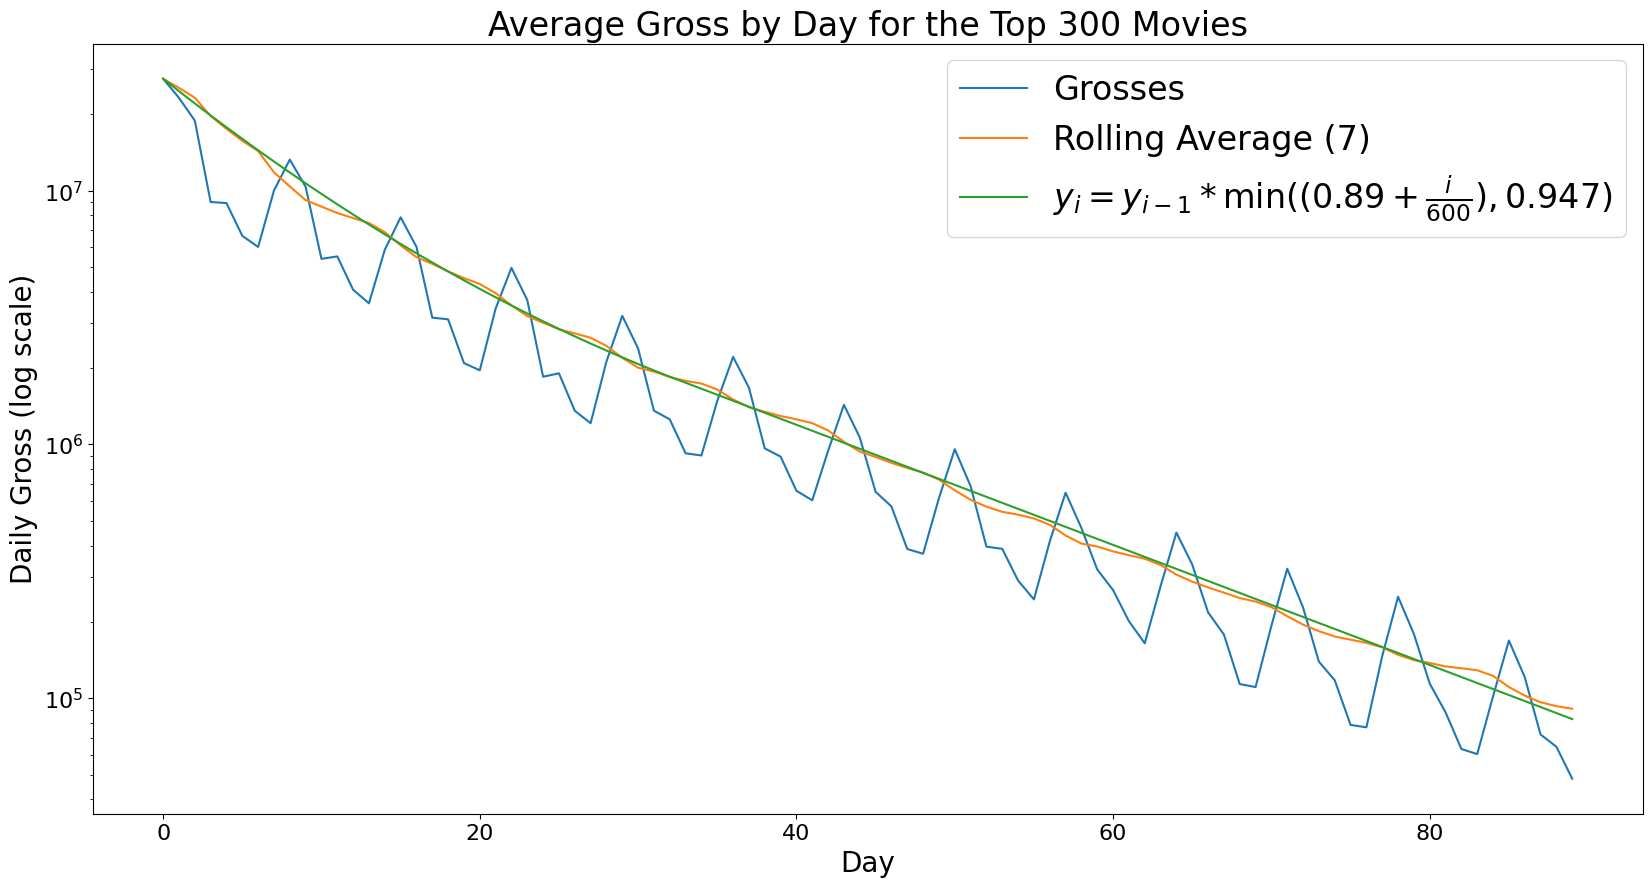

In [4]:
from matplotlib import pyplot as plt
import seaborn as sns

# average the grosses by day
grosses = []
rolling_average_value = 7
rolling_averages = []
exponential_decay_value = 0.89
min_decay_value = 0.947
day_divisor = 600
exponential_decays = []

for day in range(1, days_to_get + 1):
    gross = 0
    count = 0

    for movie in grosses_by_movie:
        if len(grosses_by_movie[movie]) >= day:
            gross += grosses_by_movie[movie][day - 1]
            count += 1

    gross /= count

    grosses.append(gross)

    # calculate the rolling average
    if len(grosses) >= rolling_average_value:
        rolling_average = sum(grosses[-rolling_average_value:]) / rolling_average_value
        rolling_averages.append(rolling_average)
    else:
        rolling_averages.append(np.mean(grosses))

    # calculate the exponential decay
    if len(exponential_decays) == 0:
        exponential_decays.append(grosses[0])
    else:
        exponential_decays.append(
            exponential_decays[-1] * min((exponential_decay_value + day / day_divisor), min_decay_value)
        )

exponential_decay_equation = f"$y_i = y_{{i-1}} * \\min(({exponential_decay_value} + \\frac{{i}}{{{day_divisor}}}), {min_decay_value})$"

# plot the grosses
plt.figure(figsize=(20, 10))
plt.plot(grosses)
plt.plot(rolling_averages)
plt.plot(exponential_decays)
plt.legend(["Grosses", f"Rolling Average ({rolling_average_value})", exponential_decay_equation], fontsize=24)
plt.xlabel("Day", fontsize=20)
plt.ylabel("Daily Gross (log scale)", fontsize=20)
plt.title("Average Gross by Day for the Top 300 Movies", fontsize=24)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# log scale the y axis
plt.yscale("log")

plt.show()

Second Drop r^2: 0.07298254054672115
Third Drop r^2: 0.0674584945916945
Fourth Drop r^2: 0.046408753890161636
Second vs Third Drop r^2: -11.894851093604387
Second vs Fourth Drop r^2: -7.263387834134894
Third vs Fourth Drop r^2: -9.245161026190408


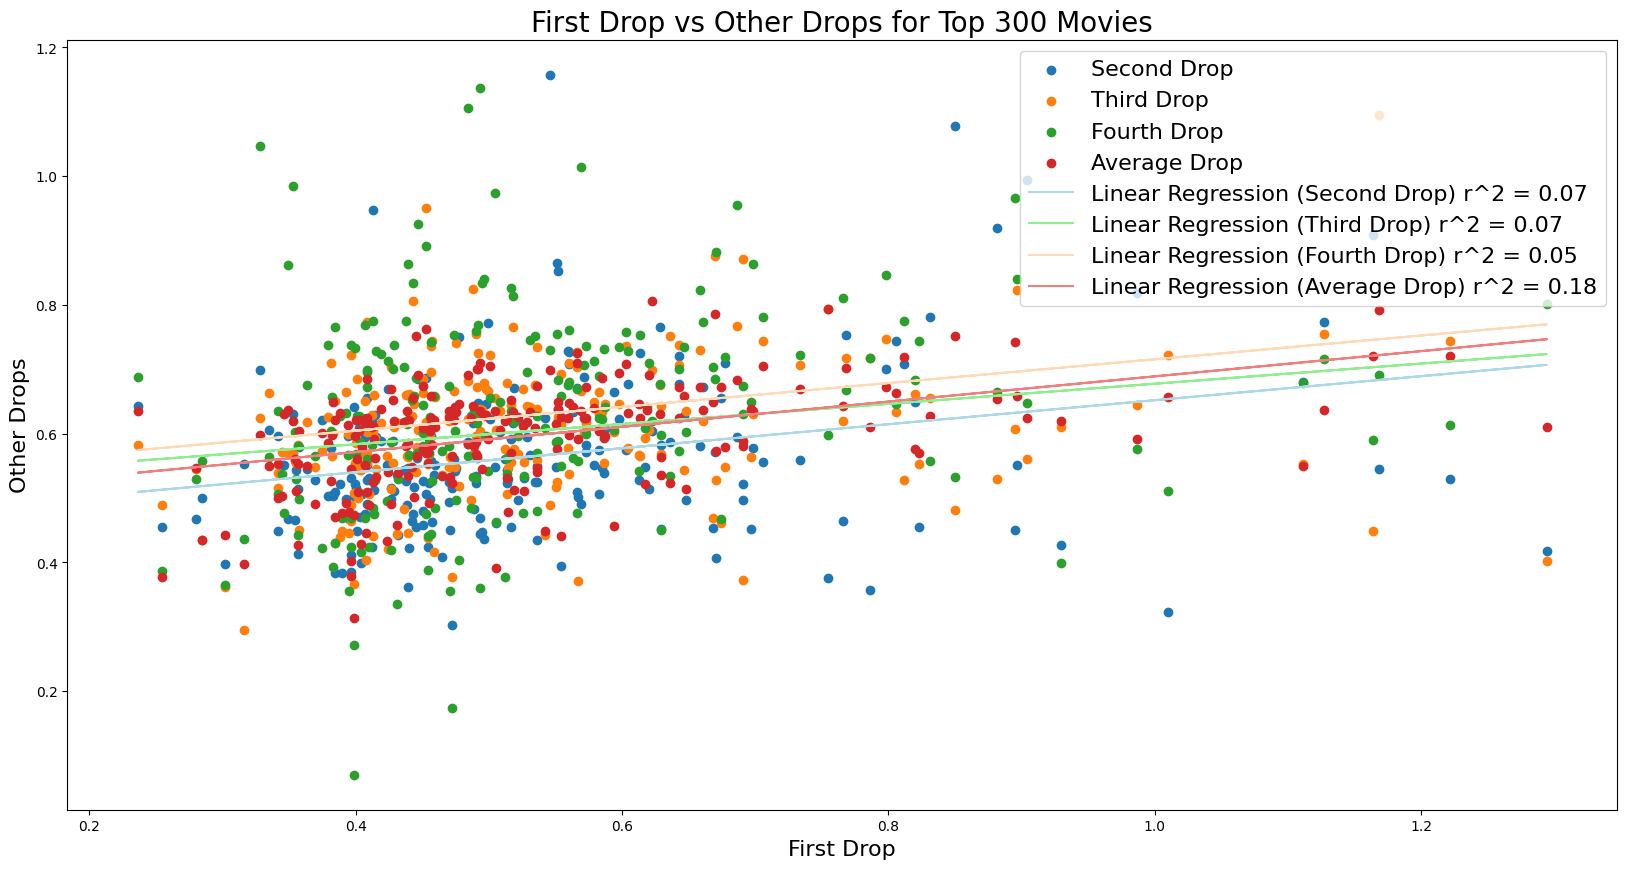

In [10]:
# now create a plot for the top 300 movies to show drop consistency
daily_grosses_by_movie: dict[str, list[int]] = {}

for movie_day in gotten_days:
    if movie_day["revenue"] is None:
        continue
    if movie_day["return_id"] not in daily_grosses_by_movie:
        daily_grosses_by_movie[movie_day["return_id"]] = []
    daily_grosses_by_movie[movie_day["return_id"]].append(movie_day["revenue"])

weekly_grosses_by_movie: dict[str, list[int]] = {}

for key, value in daily_grosses_by_movie.items():
    weekly_grosses_by_movie[key] = []
    for i in range(0, len(value), 7):
        weekly_grosses_by_movie[key].append(sum(value[i : i + 7]) / 7)

drops_by_movie: dict[str, list[float]] = {}
for key, value in weekly_grosses_by_movie.items():
    drops_by_movie[key] = []
    for i in range(1, len(value)):
        drops_by_movie[key].append(value[i] / value[i - 1])

# scatter plot first drop vs second drop
plt.figure(figsize=(20, 10))
plt.title("First Drop vs Other Drops for Top 300 Movies", fontsize=20)
plt.xlabel("First Drop", fontsize=16)
plt.ylabel("Other Drops", fontsize=16)
first_drop = []
second_drop = []
third_drop = []
fourth_drop = []
average_all_drops = []
for key, value in drops_by_movie.items():
    if len(value) == 0:
        continue
    if max(value) > 1.3:
        continue
    if len(value) < 4:
        continue
    first_drop.append(value[0])
    second_drop.append(value[1])
    third_drop.append(value[2])
    fourth_drop.append(value[3])
    average_all_drops.append(sum(value[1:]) / len(value[1:]))

# fit a linear regression to the data
first_drop = np.array(first_drop).reshape(-1, 1)
second_drop = np.array(second_drop).reshape(-1, 1)
third_drop = np.array(third_drop).reshape(-1, 1)
fourth_drop = np.array(fourth_drop).reshape(-1, 1)
average_all_drops = np.array(average_all_drops).reshape(-1, 1)

model_second = LinearRegression()
model_second.fit(first_drop, second_drop)
model_third = LinearRegression()
model_third.fit(first_drop, third_drop)
model_fourth = LinearRegression()
model_fourth.fit(first_drop, fourth_drop)
model_second_vs_third = LinearRegression()
model_second_vs_third.fit(second_drop, third_drop)
model_second_vs_fourth = LinearRegression()
model_second_vs_fourth.fit(second_drop, fourth_drop)
model_third_vs_fourth = LinearRegression()
model_third_vs_fourth.fit(third_drop, fourth_drop)
model_first_vs_average = LinearRegression()
model_first_vs_average.fit(first_drop, average_all_drops)
# print the r^2 for the linear regression
print(f"Second Drop r^2: {model_second.score(first_drop, second_drop)}")
print(f"Third Drop r^2: {model_third.score(first_drop, third_drop)}")
print(f"Fourth Drop r^2: {model_fourth.score(first_drop, fourth_drop)}")
print(f"Second vs Third Drop r^2: {model_second_vs_third.score(first_drop, second_drop + third_drop)}")
print(f"Second vs Fourth Drop r^2: {model_second_vs_fourth.score(first_drop, second_drop + fourth_drop)}")
print(f"Third vs Fourth Drop r^2: {model_third_vs_fourth.score(first_drop, third_drop + fourth_drop)}")
plt.scatter(first_drop, second_drop)
plt.scatter(first_drop, third_drop)
plt.scatter(first_drop, fourth_drop)
plt.scatter(first_drop, average_all_drops)

plt.plot(first_drop, model_second.predict(first_drop), color="lightblue")
plt.plot(first_drop, model_third.predict(first_drop), color="lightgreen")
plt.plot(first_drop, model_fourth.predict(first_drop), color="peachpuff")
plt.plot(first_drop, model_first_vs_average.predict(first_drop), color="lightcoral")
plt.legend(["Second Drop", "Third Drop", "Fourth Drop", "Average Drop", f"Linear Regression (Second Drop) r^2 = {model_second.score(first_drop, second_drop):.2f}", f"Linear Regression (Third Drop) r^2 = {model_third.score(first_drop, third_drop):.2f}", f"Linear Regression (Fourth Drop) r^2 = {model_fourth.score(first_drop, fourth_drop):.2f}", f"Linear Regression (Average Drop) r^2 = {model_first_vs_average.score(first_drop, average_all_drops):.2f}"], fontsize=16)
plt.show()

In [11]:
data = supabase.rpc(
    "get_budget_revenue"
).execute().data

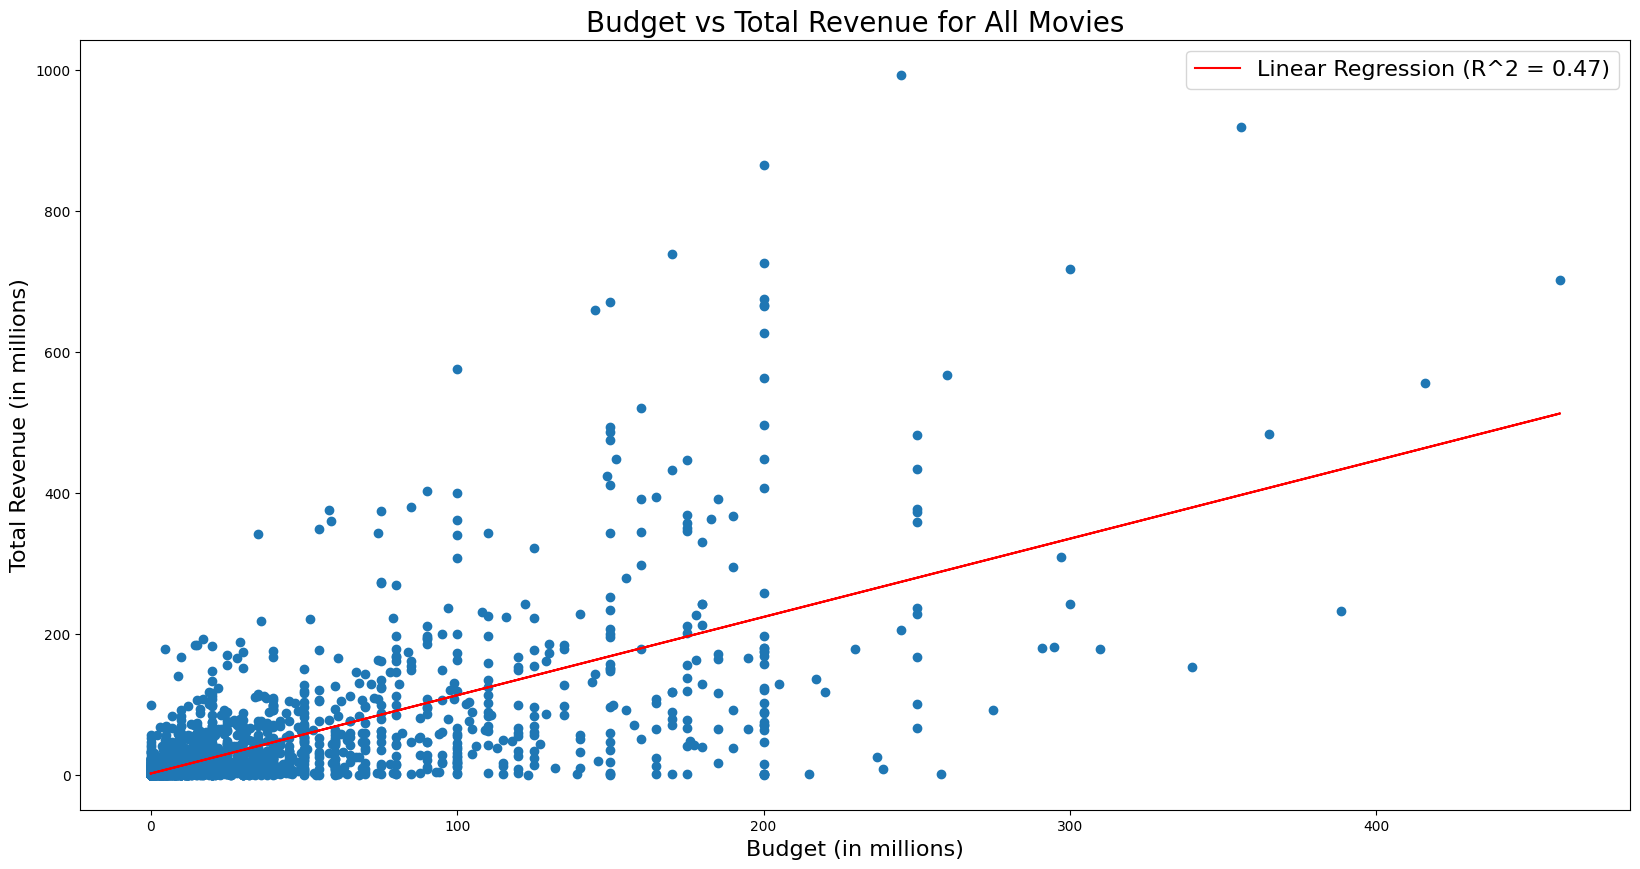

In [12]:
# plot the budget vs revenue
budgets = []
revenues = []

for movie in data:
    if movie["budget"] is not None and movie["revenue"] is not None:
        budgets.append(movie["budget"] / 1_000_000)
        revenues.append(movie["revenue"] / 1_000_000)

model = LinearRegression()
model.fit(np.array(budgets).reshape(-1, 1), np.array(revenues).reshape(-1, 1))
r_2 = model.score(
    np.array(budgets).reshape(-1, 1), np.array(revenues).reshape(-1, 1)
)
plt.figure(figsize=(20, 10))
plt.plot(
    budgets,
    model.predict(np.array(budgets).reshape(-1, 1)),
    color="red",
    label=f"Linear Regression (R^2 = {r_2:.2f})",
)
plt.xlabel("Budget (in millions)", fontsize=16)
plt.ylabel("Total Revenue (in millions)", fontsize=16)
plt.title("Budget vs Total Revenue for All Movies", fontsize=20)
plt.legend(fontsize=16)
plt.scatter(budgets, revenues)

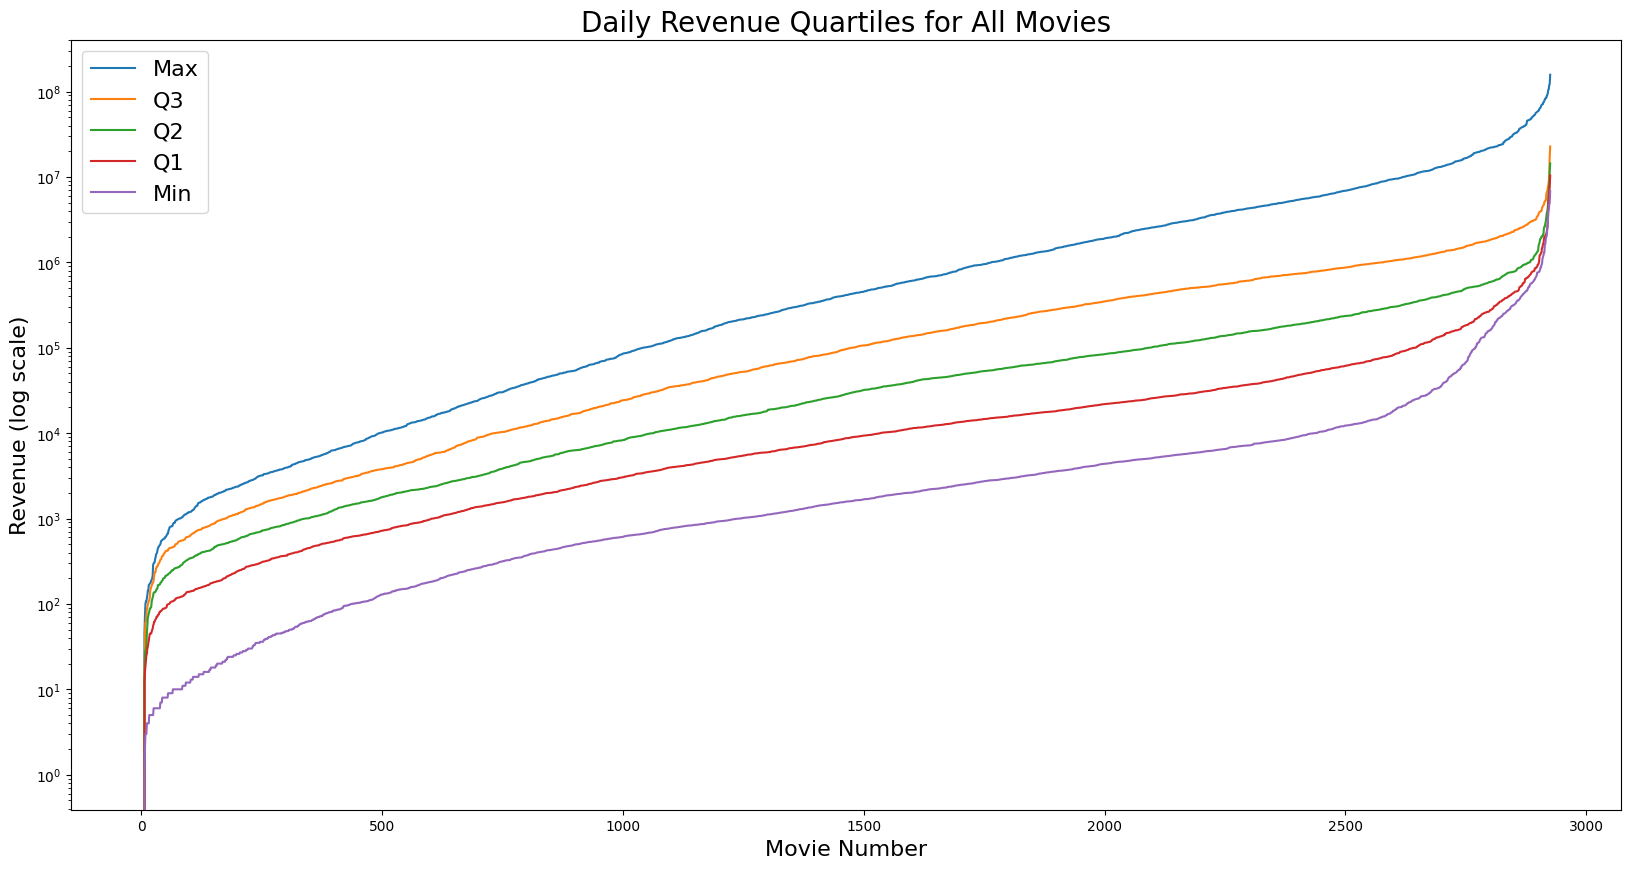

In [ ]:
quartile_data = supabase.rpc(
    "get_daily_quartiles",
).execute().data

# create a line plot
values = []

for item in quartile_data:
    values.append(
        [item["max"], item["q3"], item["q2"], item["q1"], item["min"]]
    )

# transpose the values
values = np.array(values).T

# remove NA
values = np.array(
    [
        [x if x is not None else 0 for x in y]
        for y in values
    ]
)

# sort the values
values = np.sort(values, axis=1)

# create a line plot
plt.figure(figsize=(20, 10))
plt.plot(values[0], label="Max")
plt.plot(values[1], label="Q3")
plt.plot(values[2], label="Q2")
plt.plot(values[3], label="Q1")
plt.plot(values[4], label="Min")
plt.xlabel("Movie Number", fontsize=16)
plt.ylabel("Revenue (log scale)", fontsize=16)
# log scale
plt.yscale("log")
plt.title("Daily Revenue Quartiles for All Movies", fontsize=20)
plt.legend(fontsize=16)
plt.show()


Mean Residuals
In Collection:  26008614.771895584
Not In Collection:  -3693104.3303941386
Median Residuals
In Collection:  2105882.915018855
Not In Collection:  31771.31036560578


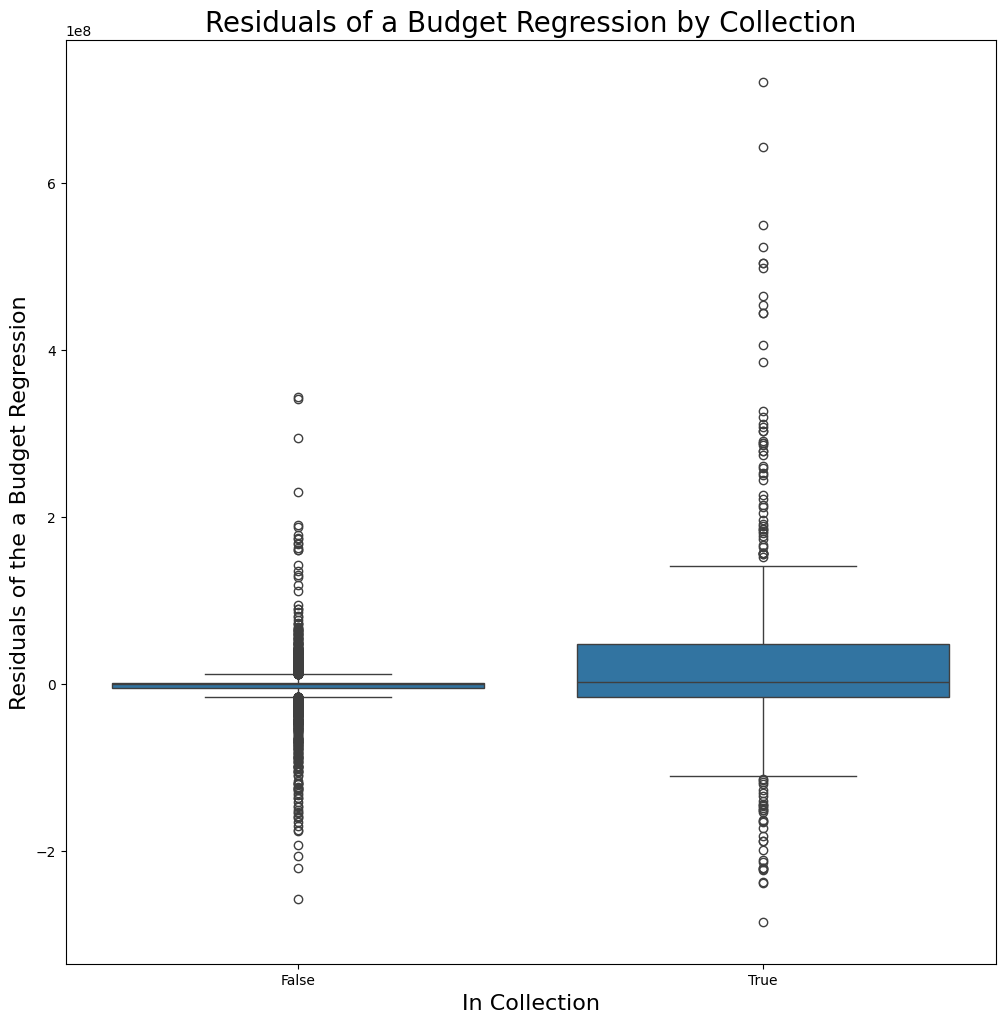

In [ ]:
# get the residuals of each movie after the budget regression
residuals = []
for movie in data:
    if movie["budget"] is not None and movie["revenue"] is not None:
        residuals.append(movie["revenue"] - model.predict(np.array(movie["budget"]).reshape(-1, 1))[0][0])

# plot the residuals based on whether the movie is in a collection
in_collection = []
for movie in data:
    if movie["budget"] is not None and movie["revenue"] is not None:
        in_collection.append(movie["collection_id"] is not None)

# box plot the residuals
plt.figure(figsize=(12, 12))
sns.boxplot(x=in_collection, y=residuals)
plt.xlabel("In Collection", fontsize=16)
plt.ylabel("Residuals of the a Budget Regression", fontsize=16)
plt.title("Residuals of a Budget Regression by Collection", fontsize=20)

# print the mean and median of the for each group
print("Mean Residuals")
print("In Collection: ", np.mean([residuals[i] for i in range(len(residuals)) if in_collection[i]]))
print("Not In Collection: ", np.mean([residuals[i] for i in range(len(residuals)) if not in_collection[i]]))
print("Median Residuals")
print("In Collection: ", np.median([residuals[i] for i in range(len(residuals)) if in_collection[i]]))
print("Not In Collection: ", np.median([residuals[i] for i in range(len(residuals)) if not in_collection[i]]))

In [ ]:
# run all the counts and figure out the most popular
genres = supabase.rpc("genre_counts").execute().data
production_countries = supabase.rpc("production_country_counts").execute().data
production_companies = supabase.rpc("production_company_counts").execute().data
spoken_languages = supabase.rpc("spoken_language_counts").execute().data
production_methods = supabase.rpc("production_method_counts").execute().data
sources = supabase.rpc("source_counts").execute().data
creative_types = supabase.rpc("creative_type_counts").execute().data
mpaa_ratings = supabase.rpc("mpaa_rating_counts").execute().data

In [ ]:
# print the top 10 of each
def print_top_x(data, row_name, x):
    print(f"Top 10 {row_name}")
    for item in data[:x]:
        print(f"{item['count']} {item[row_name]}")
    print()

print_top_x(genres, "genre", 5)
print_top_x(production_countries, "country", 5)
print_top_x(production_companies, "company", 5)
print_top_x(spoken_languages, "language", 20)
print_top_x(production_methods, "method", 5)
print_top_x(sources, "source", 5)
print_top_x(creative_types, "type", 5)
print_top_x(mpaa_ratings, "rating", 5)

Top 10 genre
1425 Drama
839 Comedy
629 Thriller
579 Action
454 Adventure

Top 10 country
2177 United States of America
487 United Kingdom
246 France
189 Canada
146 India

Top 10 company
131 Universal Pictures
99 Columbia Pictures
94 Lionsgate
91 Warner Bros. Pictures
81 Paramount Pictures

Top 10 language
2472 English
298 Español
247 Français
136 Deutsch
128 日本語
112 Italiano
106 हिन्दी
88 Português
78 普通话
77 Pусский
51 
46 العربية
34 한국어/조선말
29 Latin
24 עִבְרִית
22 svenska
20 Polski
20 Türkçe
19 తెలుగు
15 فارسی

Top 10 method
2583 Live Action
194 Digital Animation
109 Animation/Live Action
26 Hand Animation
12 Stop-Motion Animation

Top 10 source
1497 Original Screenplay
508 Based on Real Life Events
376 Based on Fiction Book/Short Story
120 Based on Factual Book/Article
117 Based on Comic/Graphic Novel

Top 10 type
1392 Contemporary Fiction
384 Dramatization
287 Historical Fiction
256 Factual
234 Science Fiction

Top 10 rating
1095 R
794 PG-13
629 NR
359 PG
40 



In [ ]:
"""2472 English
298 Español
247 Français
136 Deutsch
128 日本語
112 Italiano
106 हिन्दी
88 Português
78 普通话
77 Pусский
51 
46 العربية
34 한국어/조선말
29 Latin
24 עִבְרִית
22 svenska
20 Polski
20 Türkçe
19 తెలుగు
15 فارسی"""

# convert the spoken languages to the English name
def convert_language(language):
    if language == "English":
        return "English"
    if language == "Español":
        return "Spanish"
    if language == "Français":
        return "French"
    if language == "Deutsch":
        return "German"
    if language == "日本語":
        return "Japanese"
    if language == "Italiano":
        return "Italian"
    if language == "हिन्दी":
        return "Hindi"
    if language == "Português":
        return "Portuguese"
    if language == "普通话":
        return "Mandarin"
    if language == "Pусский":
        return "Russian"
    if language == "العربية":
        return "Arabic"
    if language == "한국어/조선말":
        return "Korean"
    if language == "Latin":
        return "Latin"
    if language == "עִבְרִית":
        return "Hebrew"
    if language == "svenska":
        return "Swedish"
    if language == "Polski":
        return "Polish"
    if language == "Türkçe":
        return "Turkish"
    if language == "తెలుగు":
        return "Telugu"
    if language == "فارسی":
        return "Persian"
    
    return language

# convert the spoken languages to the English name
for item in spoken_languages:
    item["language"] = convert_language(item["language"])

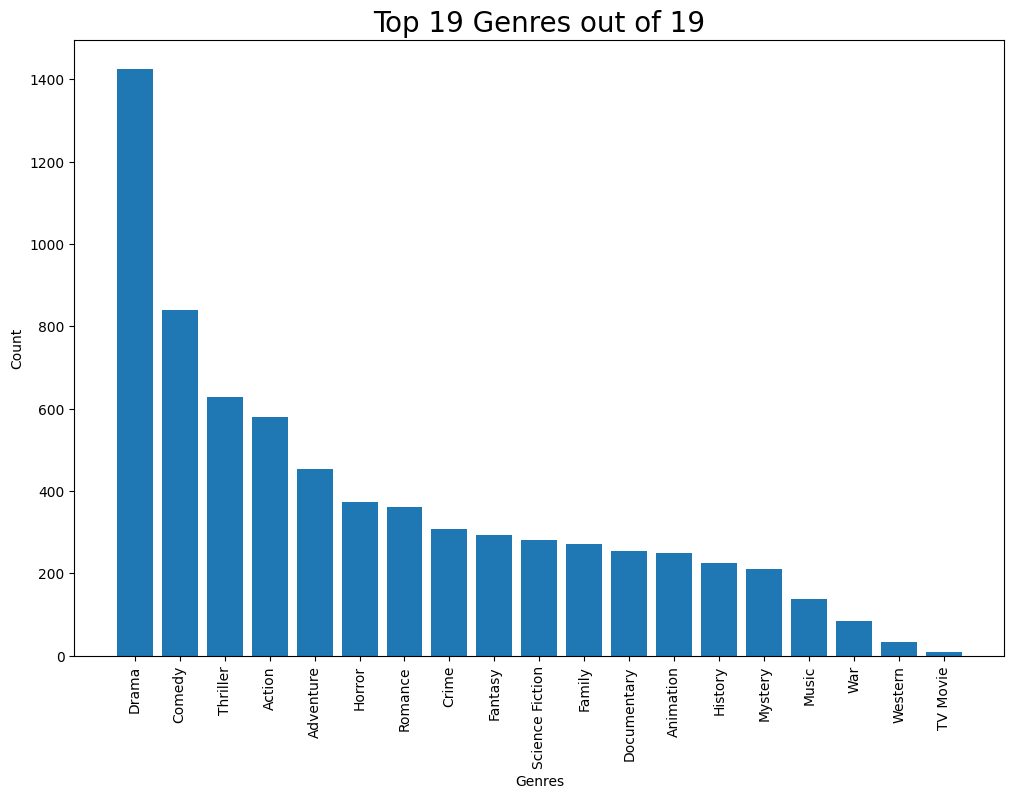

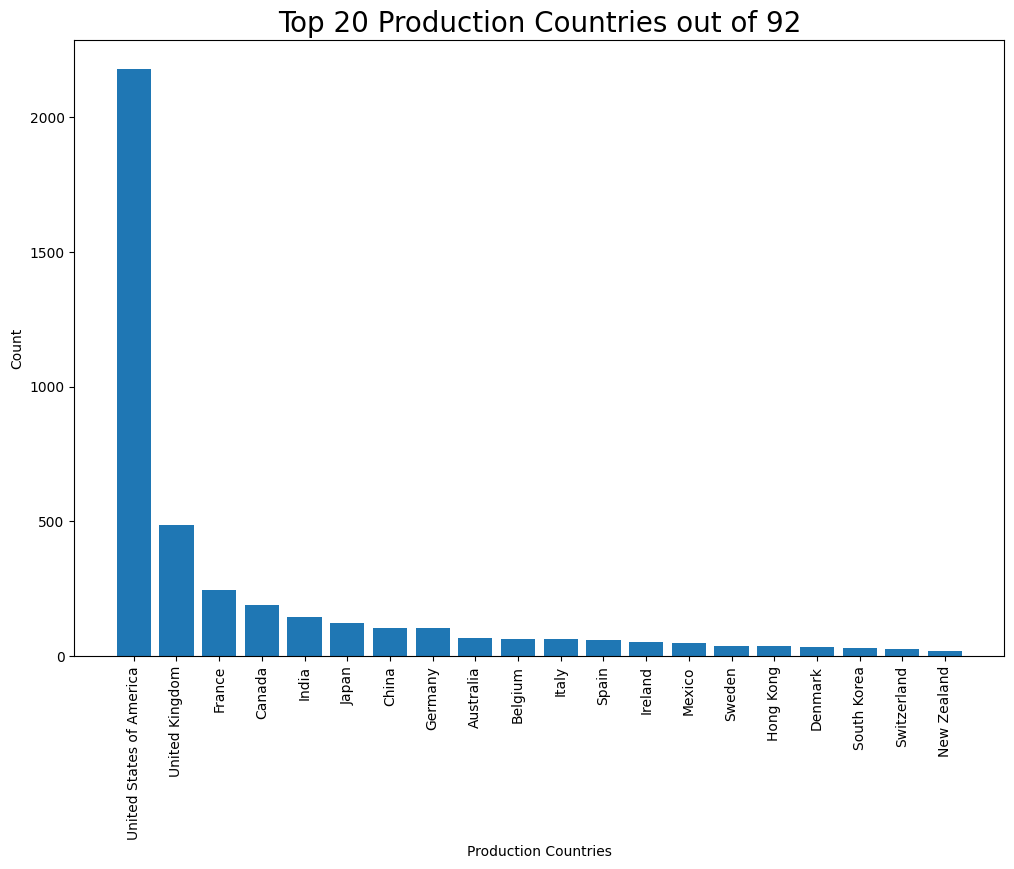

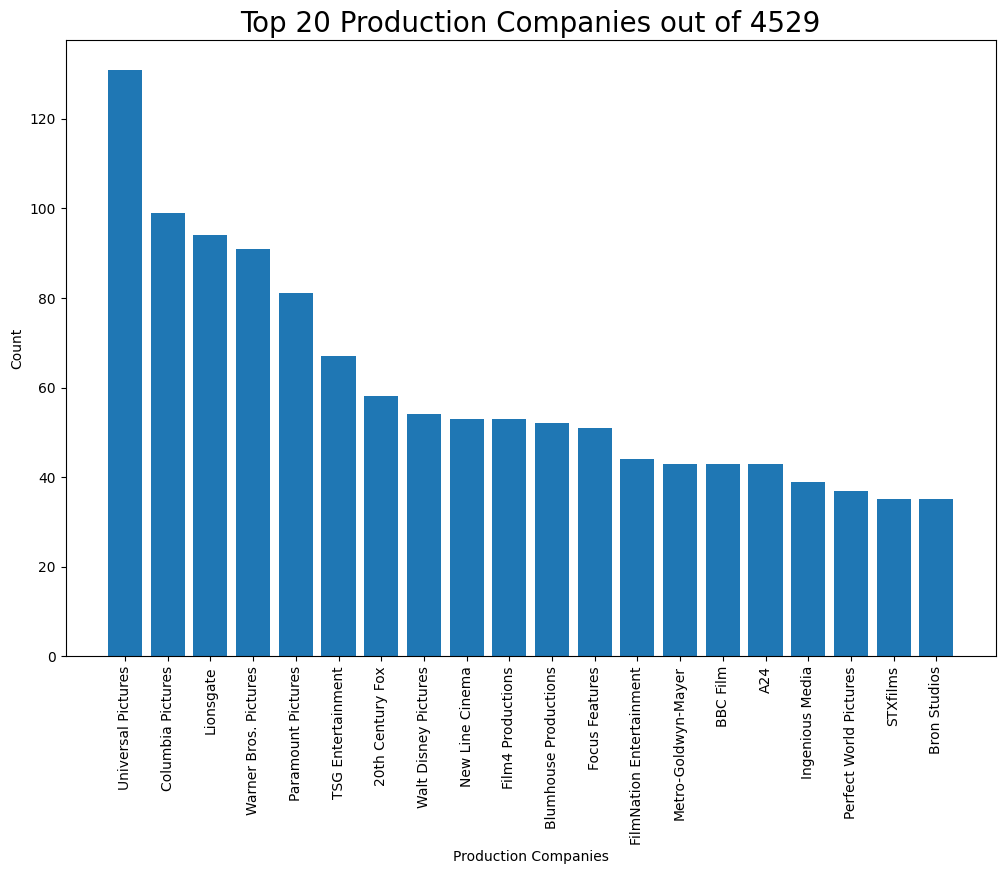

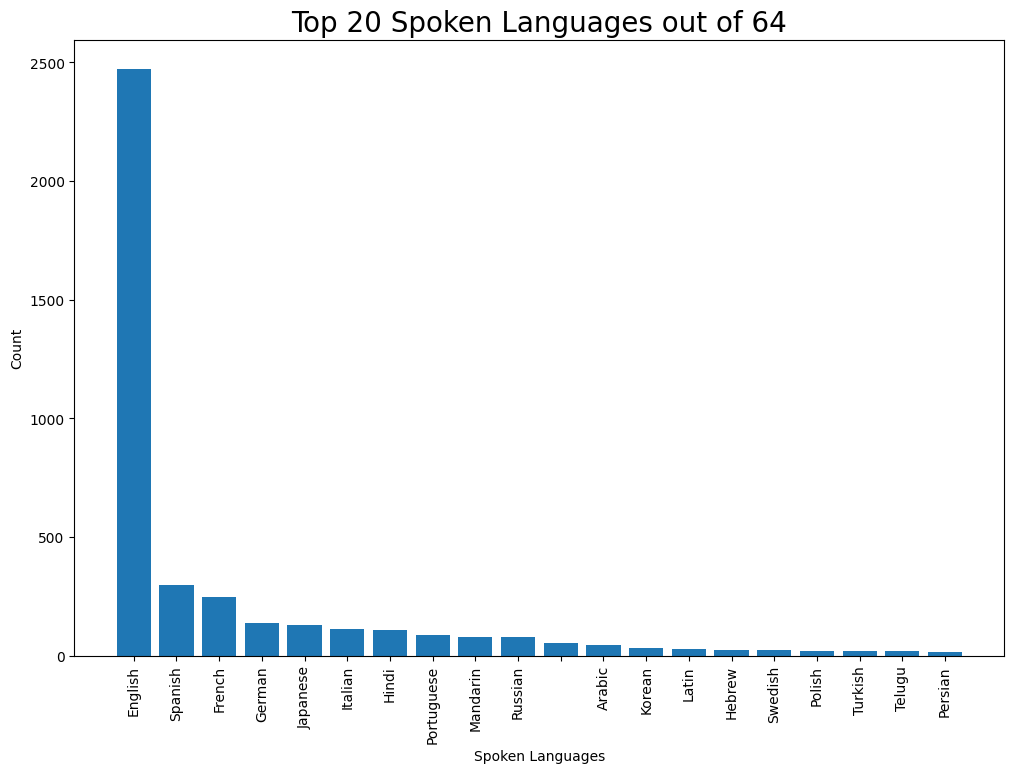

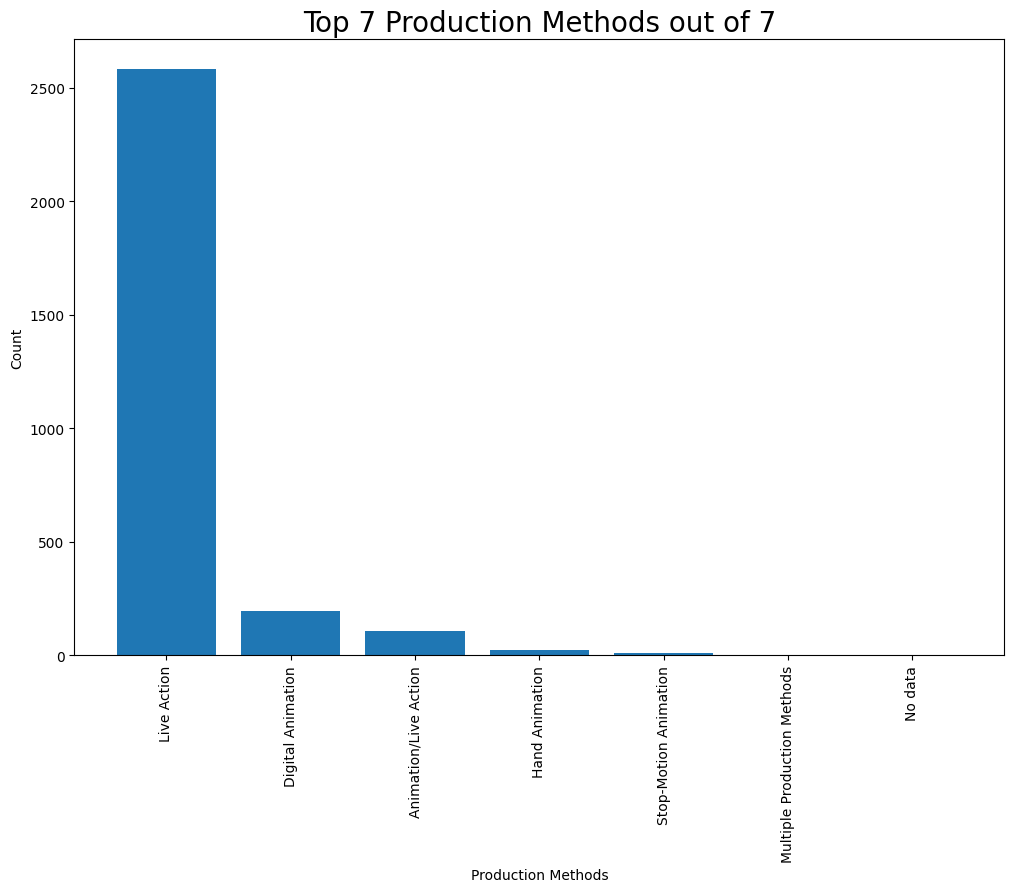

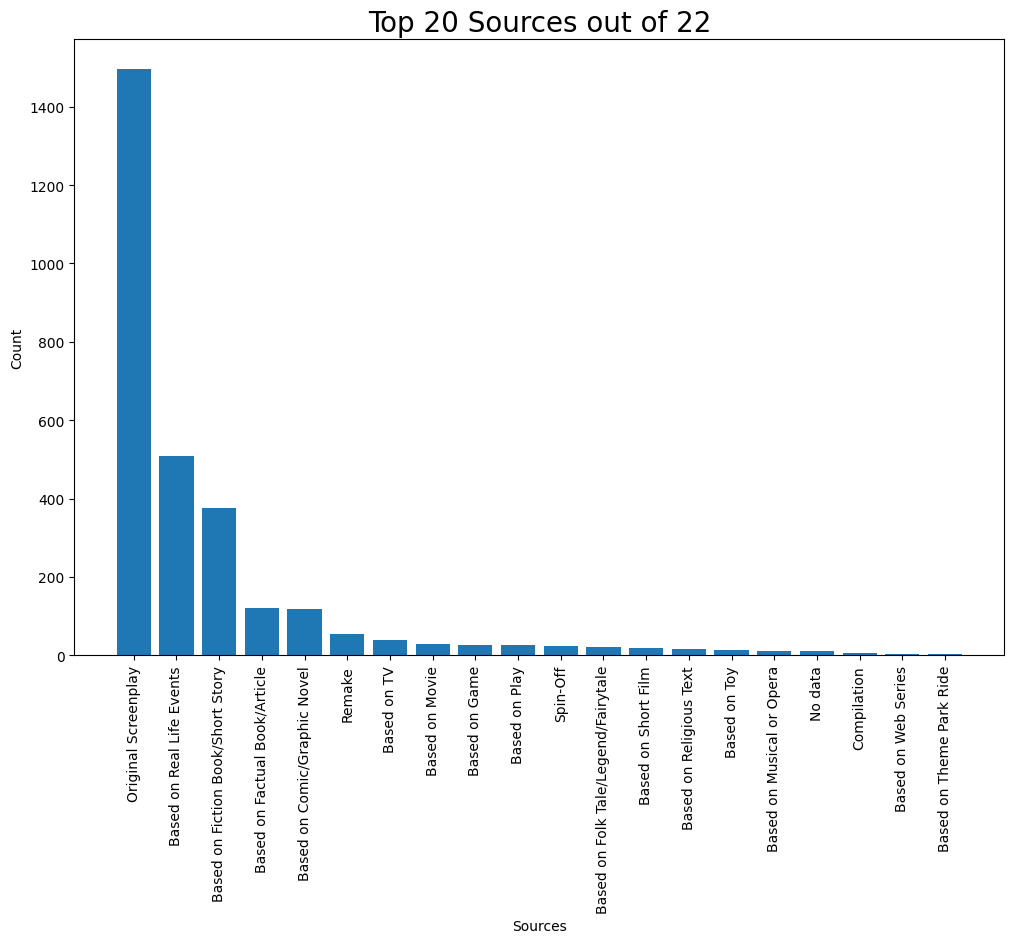

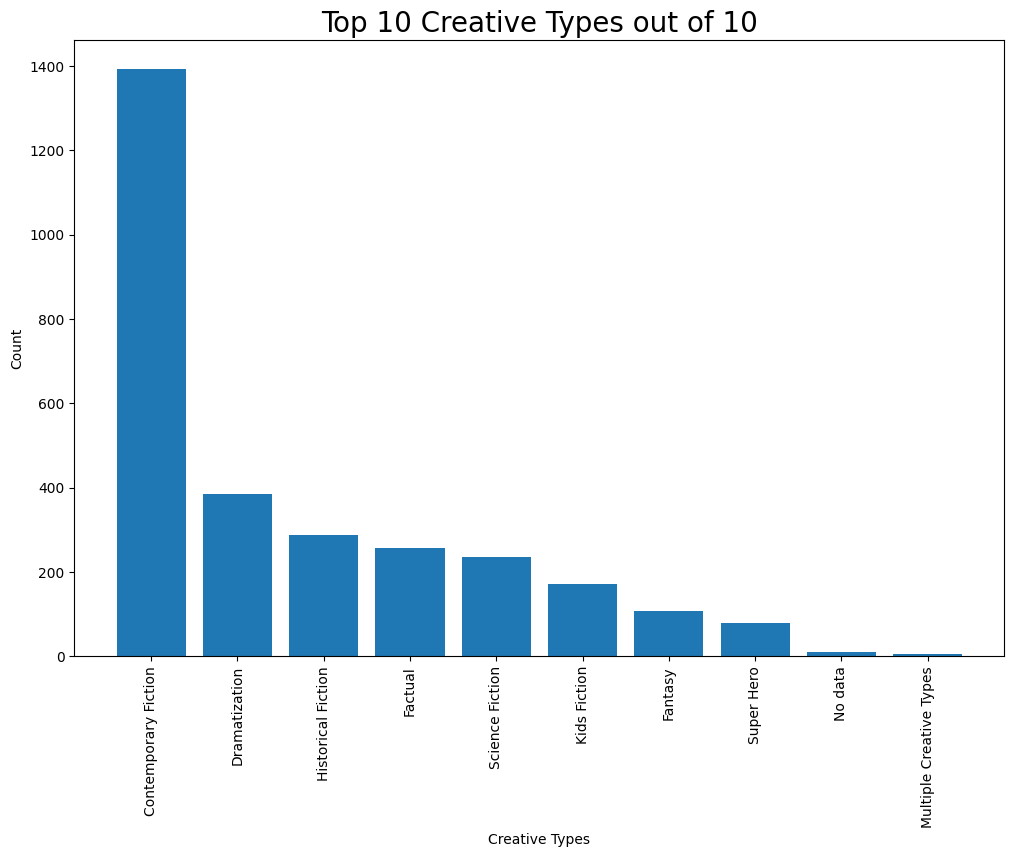

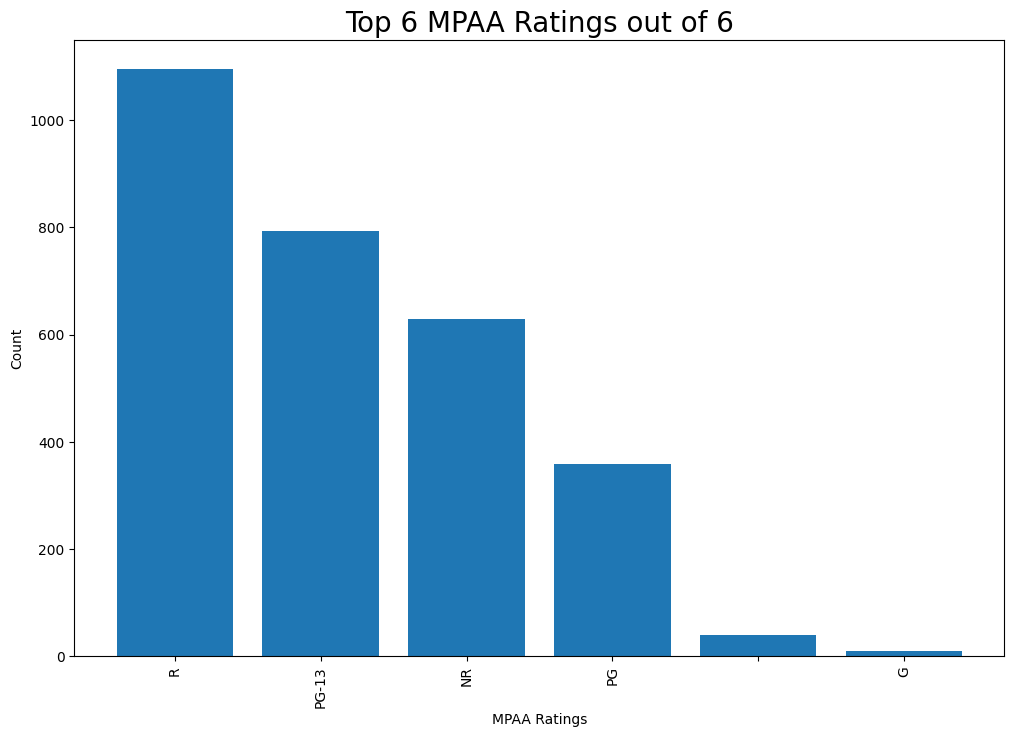

In [ ]:
def bar_plot_items(
    data, row_name, count, plural_name
):
    # create a bar plot of the top x items
    plt.figure(figsize=(12, 8))
    plt.bar(
        [item[row_name] for item in data[:count]],
        [item["count"] for item in data[:count]],
    )
    count_value = min(
        len(data), count
    )
    max_value = len(data)
    plt.title(f"Top {count_value} {plural_name} out of {max_value}", fontsize=20)
    plt.xlabel(plural_name)
    plt.ylabel("Count")
    plt.xticks(rotation=90)
    plt.show()

bar_plot_items(
    genres, "genre", 20, "Genres"
)
bar_plot_items(
    production_countries, "country", 20, "Production Countries"
)
bar_plot_items(
    production_companies, "company", 20, "Production Companies"
)
bar_plot_items(
    spoken_languages, "language", 20, "Spoken Languages"
)
bar_plot_items(
    production_methods, "method", 20, "Production Methods"
)
bar_plot_items(
    sources, "source", 20, "Sources"
)
bar_plot_items(
    creative_types, "type", 20, "Creative Types"
)
bar_plot_items(
    mpaa_ratings, "rating", 20, "MPAA Ratings"
)